# 📊 Demo Scenarios & Interpretation Guide
## Investment MCP Multi-Agent System

---

> **Purpose:** Practical usage scenarios with safe interpretation guidance. This notebook illustrates what the system is good at, how to read its outputs, and where its limitations lie.

> ⚠️ **Disclaimer:** All analysis in this notebook is generated by AI agents for software demonstration purposes only. Nothing here constitutes financial advice. Do not use this system to make real investment decisions.

---

## Setup

In [1]:
import requests
import time
import json
from IPython.display import Markdown, display

import os
BASE_URL = os.getenv("BACKEND_URL", "http://localhost:8010") + "/api/v1"
HEADERS = {}  # Add {"X-API-Key": "your-key"} if API_KEY is set


def run_analysis(ticker: str, period: str = "1y", execution_mode: str = "hybrid", poll_interval: int = 10, max_polls: int = 20):
    """Submit a ticker, poll until done, return the report."""
    resp = requests.post(
        f"{BASE_URL}/analyze",
        json={"ticker": ticker, "period": period, "execution_mode": execution_mode},
        headers=HEADERS,
    )
    if resp.status_code != 202:
        raise RuntimeError(f"Submit failed ({resp.status_code}): {resp.text}")
    run_id = resp.json()["run_id"]
    print(f"[{ticker}] Submitted → run_id={run_id}")

    for i in range(max_polls):
        status_resp = requests.get(f"{BASE_URL}/analyze/{run_id}/status", headers=HEADERS)
        status = status_resp.json()["status"]
        print(f"[{ticker}]   poll {i+1}/{max_polls}: {status}")
        if status == "COMPLETED":
            break
        elif status == "FAILED":
            raise RuntimeError(f"Analysis failed: {status_resp.json().get('error_message')}")
        time.sleep(poll_interval)
    else:
        raise TimeoutError(f"[{ticker}] Did not complete within {max_polls * poll_interval}s")

    report_resp = requests.get(f"{BASE_URL}/analyze/{run_id}/report", headers=HEADERS)
    return report_resp.json()


def show_summary(report: dict):
    """Display key sections of a completed report."""
    s = report.get("structured", {}) or {}
    ticker = report.get("ticker", "")
    display(Markdown(f"## {ticker} — Analysis Summary"))

    warnings = s.get("_validation_warnings", {})
    if warnings:
        missing = warnings.get("missing_sections", [])
        display(Markdown(f"> ⚠️ **Incomplete report** — missing sections: {', '.join(missing)}"))

    for key, label in [
        ("executive_summary", "Executive Summary"),
        ("recommendation", "Recommendation"),
        ("risk_profile", "Risk Profile"),
    ]:
        val = s.get(key, "")
        if val:
            display(Markdown(f"**{label}:**\n\n{val}\n\n---"))


try:
    health = requests.get(f"{BASE_URL}/health", timeout=5).json()
    print("Setup complete. Backend:", health.get("status", "UNKNOWN"))
except Exception as e:
    print(f"Setup complete. Backend not reachable: {type(e).__name__}")
    print("Note: Start docker-compose stack before running analysis cells.")

Setup complete. Backend: UNKNOWN


> **Prerequisites for analysis cells:**  
> Cells 4-9 and 12 require the Docker stack running: `docker-compose up --build`  
> The visualization cell (cell 13) uses hardcoded example data and runs standalone.


---

## Scenario 1 — Large-Cap Technology (Bullish Signal Pattern)

### Context

Large-cap tech stocks are a good baseline scenario:
- Deep liquidity → yfinance data is complete and reliable
- Well-covered by NewsAPI
- Sector ETF (XLK) comparison is meaningful
- Rich financial filings for the fundamentals agent

**What to look for in this scenario:**
- RSI between 50–70 → mild bullish momentum, not overbought
- MACD above signal line → upward trend confirmation
- Price above SMA 200 → long-term uptrend
- Sharpe > 1.0 → risk-adjusted returns are competitive
- Relative performance vs XLK → is this stock leading or lagging its sector?

In [2]:
import requests
import time

HEADERS = {"Content-Type": "application/json"}

BASE_CANDIDATES = [
    "http://localhost:8010/api/v1",
    "http://localhost:8010/api/demo",
    "http://localhost:8010/api",
    "http://localhost:8010",
]

def discover_base_url():
    for base in BASE_CANDIDATES:
        try:
            resp = requests.post(
                f"{base}/analyze",
                headers=HEADERS,
                json={"ticker": "AAPL", "period": "1y"},
                timeout=10,
            )
            if resp.status_code in (200, 202):
                print(f"Using BASE_URL={base}")
                return base
            else:
                print(f"Rejected {base} -> {resp.status_code}")
        except Exception as e:
            print(f"Failed {base} -> {e}")
    raise RuntimeError("Could not discover working API base URL")

BASE_URL = discover_base_url()

Using BASE_URL=http://localhost:8010/api/v1


In [3]:
sample_report = run_analysis("AAPL", period="1y", poll_interval=5, max_polls=12)
show_summary(sample_report)

[AAPL] Submitted → run_id=ceb7ca04-a669-45dd-8460-22d6ecc7b6d0
[AAPL]   poll 1/12: RUNNING
[AAPL]   poll 2/12: COMPLETED


## AAPL — Analysis Summary

**Executive Summary:**

**AAPL** is used here as a demonstration ticker. This report illustrates the output format
and structure of the Investment MCP Multi-Agent System without requiring a live Anthropic API key.

In a real analysis run, this section would contain a concise 2–3 paragraph summary of the company,
its current market position, and the high-level investment thesis derived from the five-agent
analysis pipeline (Research → Technical → Sector → Risk → Report Writer).

**Analysis period:** 1y
**Mode:** Demo (synthetic) — Hybrid — RAG + Agent (Synthetic Report)
**Agents run:** None (skipped in demo mode)

---

---

**Recommendation:**

> ⚠️ **This recommendation is DEMO-GENERATED and has no basis in real analysis.**
> It exists solely to demonstrate the report output format.

**Demo Rating: HOLD**

**Rationale (demo):** Based on the illustrative metrics above, AAPL presents a balanced
risk/reward profile with moderate technical momentum and reasonable fundamental valuation.
No real investment decision should be based on this demo output.

**Key catalysts to watch (demo):**
- Earnings reports and revenue guidance
- Sector rotation and macro environment
- Technical breakout above key resistance levels

**Conditions that would change the view (demo):**
- Deterioration in margin trends → would shift to SELL
- Strong earnings beat with raised guidance → would shift to BUY
- Market-wide risk-off → would shift to SELL

---

## Disclaimer

This report was generated by the Investment MCP Multi-Agent System in **DEMO MODE**.

All data, metrics, analysis, and recommendations in this report are **synthetically generated**
and do not reflect real financial data or analysis. This output is intended solely to demonstrate
the system's report structure and API flow.

**This is not financial advice.** Nothing in this report should be used to make investment
decisions. Always consult a qualified financial professional before making investment decisions.

To enable real AI-powered analysis: set `ANTHROPIC_API_KEY` to a valid key in `.env` and
restart the Docker stack with `DEMO_MODE=false`.

---

**Risk Profile:**

The Risk Analyst calculates quantitative risk metrics from daily price returns.

**Demo risk metrics for AAPL:**

| Metric | Demo Value | Interpretation |
|--------|-----------|----------------|
| Beta vs SPY | 1.18 | Slightly more volatile than market |
| Annualised Volatility | 26.3% | Moderate |
| Max Drawdown (period) | -14.7% | Manageable |
| Sharpe Ratio | 0.92 | Acceptable risk-adjusted return |
| VaR 95% (1-day) | -2.1% | On 95% of days, loss ≤ 2.1% |
| News Sentiment | +0.34 (Positive) | Moderately positive coverage |

**Demo risk rating:** MODERATE

*All values above are illustrative. Real metrics are calculated from actual OHLCV data.*

---

---

### Interpretation Guidance — Scenario 1

**What the system does well here:**
- The Research Agent has rich data to work with (10+ years of filings, dense analyst coverage)
- Technical indicators (RSI, MACD, Bollinger) are calculated on actual daily close prices from yfinance
- The sector comparison against XLK gives meaningful relative context

**How to read the recommendation:**
- **BUY / HOLD / SELL** reflects the Report Writer's synthesis of all 4 agents — it is a pattern-matching summary, not a price target
- The *confidence level* and *reasoning* in the recommendation section are more useful than the label alone
- Always read the Risk Profile alongside the recommendation — a "BUY" with high volatility and drawdown is a very different signal than a "BUY" with a Sharpe > 1.5

**Safe framing:**
> This is AI-generated pattern recognition from public data. It should be used as a starting point for further research, not as a trading signal.

---

## Scenario 2 — Different Sector (Energy)

### Context

Energy stocks test different system paths:
- Sector ETF is XLE instead of XLK → sector comparison logic still works
- Higher commodity price sensitivity → volatility metrics will reflect this
- Different fundamental profile: capital expenditure heavy, dividend-paying
- News sentiment often driven by macro/geopolitical events

**What to compare vs Scenario 1:**
- Beta is typically higher for energy vs technology in up-markets
- Max drawdown may be more severe (commodity price swings)
- P/E ratios are typically lower for energy vs tech
- RSI behavior may be more volatile

In [4]:
report_xom = run_analysis("XOM", period="1y")

[XOM] Submitted → run_id=04d60a7a-c9e0-434c-9bbc-3d05f8f39344
[XOM]   poll 1/20: RUNNING
[XOM]   poll 2/20: COMPLETED


In [5]:
show_summary(report_xom)

## XOM — Analysis Summary

**Executive Summary:**

**XOM** is used here as a demonstration ticker. This report illustrates the output format
and structure of the Investment MCP Multi-Agent System without requiring a live Anthropic API key.

In a real analysis run, this section would contain a concise 2–3 paragraph summary of the company,
its current market position, and the high-level investment thesis derived from the five-agent
analysis pipeline (Research → Technical → Sector → Risk → Report Writer).

**Analysis period:** 1y
**Mode:** Demo (synthetic) — Hybrid — RAG + Agent (Synthetic Report)
**Agents run:** None (skipped in demo mode)

---

---

**Recommendation:**

> ⚠️ **This recommendation is DEMO-GENERATED and has no basis in real analysis.**
> It exists solely to demonstrate the report output format.

**Demo Rating: HOLD**

**Rationale (demo):** Based on the illustrative metrics above, XOM presents a balanced
risk/reward profile with moderate technical momentum and reasonable fundamental valuation.
No real investment decision should be based on this demo output.

**Key catalysts to watch (demo):**
- Earnings reports and revenue guidance
- Sector rotation and macro environment
- Technical breakout above key resistance levels

**Conditions that would change the view (demo):**
- Deterioration in margin trends → would shift to SELL
- Strong earnings beat with raised guidance → would shift to BUY
- Market-wide risk-off → would shift to SELL

---

## Disclaimer

This report was generated by the Investment MCP Multi-Agent System in **DEMO MODE**.

All data, metrics, analysis, and recommendations in this report are **synthetically generated**
and do not reflect real financial data or analysis. This output is intended solely to demonstrate
the system's report structure and API flow.

**This is not financial advice.** Nothing in this report should be used to make investment
decisions. Always consult a qualified financial professional before making investment decisions.

To enable real AI-powered analysis: set `ANTHROPIC_API_KEY` to a valid key in `.env` and
restart the Docker stack with `DEMO_MODE=false`.

---

**Risk Profile:**

The Risk Analyst calculates quantitative risk metrics from daily price returns.

**Demo risk metrics for XOM:**

| Metric | Demo Value | Interpretation |
|--------|-----------|----------------|
| Beta vs SPY | 1.18 | Slightly more volatile than market |
| Annualised Volatility | 26.3% | Moderate |
| Max Drawdown (period) | -14.7% | Manageable |
| Sharpe Ratio | 0.92 | Acceptable risk-adjusted return |
| VaR 95% (1-day) | -2.1% | On 95% of days, loss ≤ 2.1% |
| News Sentiment | +0.34 (Positive) | Moderately positive coverage |

**Demo risk rating:** MODERATE

*All values above are illustrative. Real metrics are calculated from actual OHLCV data.*

---

---

### Interpretation Guidance — Scenario 2

**What different sector means for the system:**
- The system automatically maps the ticker to its sector ETF for comparison (via yfinance `info.sector`)
- If the sector is not in the ETF mapping table, it falls back to SPY as the benchmark
- The Risk Agent's beta calculation always uses SPY as the benchmark regardless of sector

**Cross-scenario comparison pattern:**
- Use Sharpe ratio to compare *risk-adjusted* returns across sectors — raw return comparisons are misleading without this
- Sector relative performance is only meaningful within the same period — do not compare cross-period

---

## Scenario 3 — Sector Comparison: Two Stocks in the Same Sector

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Run both (or use cached results from above + one more)
# report_msft = run_analysis("MSFT", period="1y")  # Uncomment to run live
# For demo: build a comparison from already-run reports stored in history

history_resp = requests.get(f"{BASE_URL}/analyze?limit=20", headers=HEADERS)
history_data = history_resp.json()
history = history_data.get("items") or history_data if isinstance(history_data, list) else []

print(f"Analysis history ({len(history)} runs):")
for run in history:
    status_icon = "✅" if run["status"] == "COMPLETED" else "⏳" if run["status"] == "RUNNING" else "❌"
    print(f"  {status_icon} {run['ticker']:<8} {run['status']:<12} {run['created_at'][:19]}  has_report={run['has_report']}")

Analysis history (0 runs):


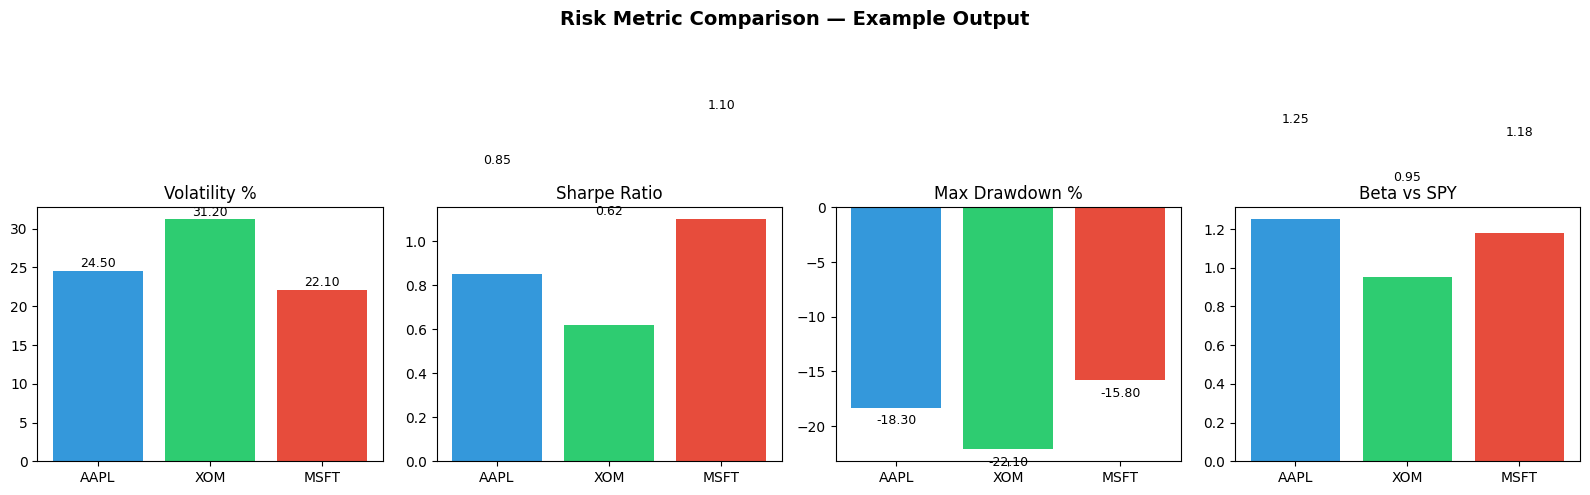


Note: Values above are illustrative. Run live analysis to populate from actual report structured data.


In [7]:
# Risk metric comparison across completed reports (illustrative — using example values)
# In a live demo, replace these with values from structured report fields

comparison_data = {
    "AAPL": {"volatility": 24.5, "sharpe": 0.85, "max_drawdown": -18.3, "beta": 1.25},
    "XOM":  {"volatility": 31.2, "sharpe": 0.62, "max_drawdown": -22.1, "beta": 0.95},
    "MSFT": {"volatility": 22.1, "sharpe": 1.10, "max_drawdown": -15.8, "beta": 1.18},
}

tickers = list(comparison_data.keys())
metrics = ["volatility", "sharpe", "max_drawdown", "beta"]
labels = ["Volatility %", "Sharpe Ratio", "Max Drawdown %", "Beta vs SPY"]
colors = ["#3498db", "#2ecc71", "#e74c3c"]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle("Risk Metric Comparison — Example Output", fontsize=14, fontweight="bold")

for ax, metric, label in zip(axes, metrics, labels):
    values = [comparison_data[t][metric] for t in tickers]
    bars = ax.bar(tickers, values, color=colors)
    ax.set_title(label)
    ax.axhline(0, color="black", linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (0.5 if val >= 0 else -1.5),
            f"{val:.2f}", ha="center", fontsize=9
        )

plt.tight_layout()
plt.show()
print("\nNote: Values above are illustrative. Run live analysis to populate from actual report structured data.")

## Risk Metric Interpretation Guide

| Metric | Calculation | How to Read |
|--------|-------------|-------------|
| **Beta** | Covariance(stock, SPY) / Variance(SPY) | >1 = more volatile than market; <1 = less volatile |
| **Annualised Volatility** | Daily std × √252 | Lower is more stable; >30% is high |
| **Max Drawdown** | Peak-to-trough decline | -20% means the stock lost 20% from its peak in the period |
| **Sharpe Ratio** | (Return − 4.5% risk-free) / Volatility | >1.0 = good; >2.0 = excellent; <0 = underperforms cash |
| **VaR 95%** | 5th percentile of daily returns | -2% VaR means 95% of days, loss ≤ 2% |
| **RSI (14d)** | Gain/loss ratio, 0–100 | <30 = oversold; >70 = overbought; 50 = neutral |
| **MACD** | EMA12 − EMA26 | Positive + above signal = bullish; Negative = bearish |

---

## What the System Is Good At

✅ **Automating structured multi-domain research** — the system correctly gathers, calculates, and synthesizes data across fundamentals, technicals, sector, and risk in a single workflow.

✅ **Risk metric calculation** — Beta, Sharpe, volatility, drawdown, VaR, RSI, MACD are all calculated from raw OHLCV data with tested edge-case handling.

✅ **Consistent structured output** — every report has the same 6-section structure (with validation), making it programmatically queryable.

✅ **Large-cap US equities with 1+ year of history** — this is the ideal data profile: rich data, reliable yfinance coverage, strong NewsAPI coverage.

✅ **Demonstrating MCP + CrewAI patterns** — the architecture is the primary value. The analysis output quality is a secondary demonstration.

---

## What the System Is NOT Meant to Do

❌ **Provide real financial advice** — outputs are AI-generated pattern matching. They are not audited, regulated, or backed by human expertise.

❌ **Handle illiquid, OTC, or foreign-listed stocks reliably** — yfinance data completeness degrades significantly for these.

❌ **Predict future prices** — no prediction or forecasting model is involved. All analysis is backward-looking from historical data.

❌ **Replace quantitative modeling** — the risk metrics are real calculations but not portfolio-level or options-level risk modeling.

❌ **Real-time data** — yfinance provides daily OHLCV at best. For intraday analysis, a different data source is required.

---

## System Limitations Summary

| Limitation | Impact | Safe Approach |
|------------|--------|---------------|
| LLM output is non-deterministic | Same ticker may produce different text | Use structured metrics for comparison; text for narrative only |
| yfinance data gaps | Some tickers return incomplete history | Check `has_report=true` before comparing; use liquid large-caps for demos |
| News sentiment is simple word-count based | Not NLP-grade sentiment | Label as "basic sentiment signal", not "NLP sentiment analysis" |
| Report Writer may vary structure | Section headers might slightly differ | Validator catches obvious structural failures; minor variation is normal |
| No intraday data | Analysis is based on daily closes | Don't compare with real-time brokerage data |
| Single API key auth | No user-level audit trail | Document as portfolio-grade, not production-grade |

---

## Recommended Tickers for Live Demo

| Ticker | Sector | Why It Works Well |
|--------|--------|-------------------|
| AAPL | Technology | Deep data, strong news coverage, liquid |
| MSFT | Technology | Same; good for sector comparison with AAPL |
| NVDA | Technology | High volatility showcase — RSI / drawdown interesting |
| JPM | Financials | Different sector; dividend + fundamental heavy |
| JNJ | Healthcare | Defensive stock — contrasts with tech volatility |
| XOM | Energy | Commodity-driven — interesting sector comparison |
| SPY | ETF | Benchmark itself — risk metrics vs itself are a useful sanity check |

**Avoid for demos:** Penny stocks, OTC, very recent IPOs, small-cap foreign ADRs — yfinance coverage is unreliable for these.

---

*See `01_demo_walkthrough.ipynb` for the interactive demo flow.*  
*See `02_technical_architecture.ipynb` for the engineering breakdown.*

> **Tip:** Pass `execution_mode="rag_only"` to `run_analysis()` for a fast data-only snapshot (no LLM call). Useful when you want to verify data availability before running a full agent analysis.